<a href="https://colab.research.google.com/github/Aryaa245/Drug-side-effect-Detection-in-medical-text-with-RoBERTa/blob/Percobaan-2/Drug_side_effect_Detection_in_medical_text_with_RoBERTa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Drug Side Effect Detection — RoBERTa Fine-tuning Pipeline

**Dataset**: ADE-Corpus-V2 (Gurulingappa et al., 2012)  
**Model**: RoBERTa-base  
**Fitur Utama**:
- ✅ EDA & Dataset Tracking (distribusi, statistik, versi)
- ✅ Handling Imbalanced Data (Class Weight + Focal Loss + Threshold Tuning)
- ✅ Multi-experiment Training (3 strategi imbalance)
- ✅ MLflow Experiment Logging (metrics, params, artifacts)
- ✅ Pemilihan Model Terbaik otomatis
- ✅ Evaluasi Final & Confusion Matrix

---

## 📦 CELL 1 — Instalasi Library

In [1]:
# Install semua dependensi
!pip install -q transformers datasets scikit-learn torch torchvision
!pip install -q mlflow seaborn matplotlib pandas numpy
!pip install -q accelerate -U

print('✅ Semua library berhasil diinstall!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

## 📚 CELL 2 — Import Library

In [2]:
# ── Standard Library ──
import os
import json
import time
import hashlib
import warnings
import datetime
warnings.filterwarnings('ignore')

# ── Data ──
import numpy as np
import pandas as pd
from datasets import load_dataset

# ── Visualisasi ──
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Scikit-learn ──
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve
)

# ── PyTorch ──
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── HuggingFace Transformers ──
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

# ── MLflow ──
import mlflow
import mlflow.pytorch

# ── Device setup ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## 📥 CELL 3 — Load Dataset & Dataset Tracking

In [3]:
# =============================================
# Load Dataset dari HuggingFace
# =============================================
print('📥 Memuat ADE-Corpus-V2 dari HuggingFace...')
raw = load_dataset('ade_corpus_v2', 'Ade_corpus_v2_classification')

# Gabungkan semua split
all_data = []
for split in raw:
    for item in raw[split]:
        all_data.append({'text': item['text'], 'label': item['label']})

df = pd.DataFrame(all_data).drop_duplicates(subset='text').reset_index(drop=True)

print(f'✅ Dataset berhasil dimuat: {len(df):,} sampel unik')

# =============================================
# DATASET TRACKING — Metadata & Versioning
# =============================================
print('\n' + '='*55)
print('📋 DATASET TRACKING & VERSIONING')
print('='*55)

# Buat hash dataset untuk versioning
dataset_str = df['text'].str.cat(sep='|')
dataset_hash = hashlib.md5(dataset_str.encode()).hexdigest()[:12]

# Metadata dataset
dataset_metadata = {
    'dataset_name'    : 'ADE-Corpus-V2 (Classification)',
    'source'          : 'Gurulingappa et al., 2012 — HuggingFace Hub',
    'version_hash'    : dataset_hash,
    'loaded_at'       : datetime.datetime.now().isoformat(),
    'total_samples'   : len(df),
    'num_features'    : len(df.columns),
    'num_classes'     : df['label'].nunique(),
    'class_names'     : {0: 'Non-ADE', 1: 'ADE'},
    'class_counts'    : df['label'].value_counts().to_dict(),
    'class_ratio'     : round(df['label'].value_counts(normalize=True).to_dict()[0], 4),
    'has_nulls'       : df.isnull().sum().sum(),
    'has_duplicates'  : 0,  # sudah di-drop
}

for k, v in dataset_metadata.items():
    print(f'  {k:<22}: {v}')

# Simpan metadata ke JSON
with open('dataset_metadata.json', 'w') as f:
    json.dump(dataset_metadata, f, indent=2, default=str)
print('\n💾 Metadata disimpan ke: dataset_metadata.json')

📥 Memuat ADE-Corpus-V2 dari HuggingFace...


README.md: 0.00B [00:00, ?B/s]

Ade_corpus_v2_classification/train-00000(…):   0%|          | 0.00/1.71M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23516 [00:00<?, ? examples/s]

✅ Dataset berhasil dimuat: 20,896 sampel unik

📋 DATASET TRACKING & VERSIONING
  dataset_name          : ADE-Corpus-V2 (Classification)
  source                : Gurulingappa et al., 2012 — HuggingFace Hub
  version_hash          : 10469a693dd4
  loaded_at             : 2026-04-30T14:23:21.449987
  total_samples         : 20896
  num_features          : 2
  num_classes           : 2
  class_names           : {0: 'Non-ADE', 1: 'ADE'}
  class_counts          : {0: 16625, 1: 4271}
  class_ratio           : 0.7956
  has_nulls             : 0
  has_duplicates        : 0

💾 Metadata disimpan ke: dataset_metadata.json


## 📊 CELL 4 — EDA (Exploratory Data Analysis)

📊 DISTRIBUSI LABEL
  Label 0 (Non-ADE (0)): 16,625   79.6%  ███████████████████████████████████████
  Label 1 (ADE (1)):  4,271   20.4%  ██████████
  Rasio imbalance: 1 : 3.89


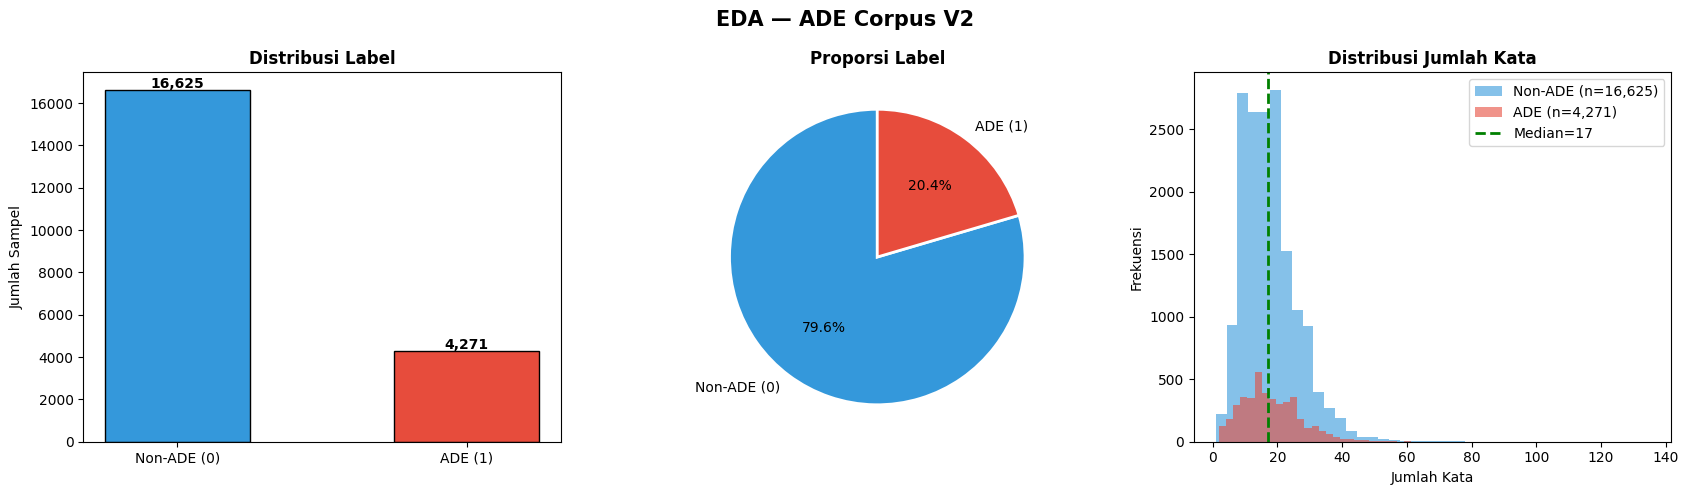


📏 STATISTIK PANJANG TEKS PER LABEL:
      text_length                                               word_count                                         
            count   mean   std   min   25%    50%    75%    max      count  mean  std  min   25%   50%   75%    max
label                                                                                                              
0         16625.0  125.1  57.7   7.0  84.0  116.0  156.0  742.0    16625.0  17.8  8.5  1.0  12.0  16.0  22.0  135.0
1          4271.0  132.2  60.7  17.0  87.0  124.0  168.0  568.0     4271.0  18.0  9.1  2.0  11.0  17.0  23.0   90.0


In [4]:
# ── Fitur panjang teks ──
df['text_length'] = df['text'].apply(len)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))

label_counts = df['label'].value_counts()
label_names  = {0: 'Non-ADE (0)', 1: 'ADE (1)'}

print('='*55)
print('📊 DISTRIBUSI LABEL')
print('='*55)
for lbl, cnt in label_counts.items():
    pct = cnt / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'  Label {lbl} ({label_names[lbl]}): {cnt:>6,}  {pct:5.1f}%  {bar}')
print(f'  Rasio imbalance: 1 : {label_counts[0]/label_counts[1]:.2f}')

# ── Plot ──
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('EDA — ADE Corpus V2', fontsize=15, fontweight='bold')

# Bar chart
colors = ['#3498db', '#e74c3c']
axes[0].bar(label_names.values(), label_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Label', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_names.values(),
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Label', fontweight='bold')

# Histogram word count
for lbl, color, name in [(0, '#3498db', 'Non-ADE'), (1, '#e74c3c', 'ADE')]:
    subset = df[df['label'] == lbl]['word_count']
    axes[2].hist(subset, bins=40, alpha=0.6, color=color, label=f'{name} (n={len(subset):,})')
axes[2].axvline(df['word_count'].median(), color='green', linestyle='--', lw=2, label=f'Median={df["word_count"].median():.0f}')
axes[2].set_title('Distribusi Jumlah Kata', fontweight='bold')
axes[2].set_xlabel('Jumlah Kata')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📏 STATISTIK PANJANG TEKS PER LABEL:')
print(df.groupby('label')[['text_length', 'word_count']].describe().round(1).to_string())

## ✂️ CELL 5 — Data Splitting (Stratified)

In [5]:
texts  = df['text'].tolist()
labels = df['label'].tolist()

# Split 70 / 15 / 15 dengan stratifikasi
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    texts, labels, test_size=0.30, random_state=42, stratify=labels
)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.50, random_state=42, stratify=temp_labels
)

print('✅ Dataset berhasil dibagi:')
print(f'  🔵 Train      : {len(train_texts):>6,} sampel ({len(train_texts)/len(texts)*100:.1f}%)')
print(f'  🟡 Validation : {len(val_texts):>6,} sampel ({len(val_texts)/len(texts)*100:.1f}%)')
print(f'  🔴 Test       : {len(test_texts):>6,} sampel ({len(test_texts)/len(texts)*100:.1f}%)')

# Verifikasi stratifikasi
print('\n📊 Verifikasi distribusi label per split:')
for name, lbls in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    arr = np.array(lbls)
    pct0 = (arr == 0).mean() * 100
    pct1 = (arr == 1).mean() * 100
    print(f'  {name:<6}: Non-ADE={pct0:.1f}%  ADE={pct1:.1f}%  ✅')

# Dataset tracking — split info
split_info = {
    'train_size': len(train_texts),
    'val_size'  : len(val_texts),
    'test_size' : len(test_texts),
    'strategy'  : 'stratified 70/15/15',
    'random_state': 42,
}
with open('split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)
print('\n💾 Split info disimpan ke: split_info.json')

✅ Dataset berhasil dibagi:
  🔵 Train      : 14,627 sampel (70.0%)
  🟡 Validation :  3,134 sampel (15.0%)
  🔴 Test       :  3,135 sampel (15.0%)

📊 Verifikasi distribusi label per split:
  Train : Non-ADE=79.6%  ADE=20.4%  ✅
  Val   : Non-ADE=79.6%  ADE=20.4%  ✅
  Test  : Non-ADE=79.6%  ADE=20.4%  ✅

💾 Split info disimpan ke: split_info.json


## 🔤 CELL 6 — Tokenisasi & PyTorch Dataset

In [6]:
MODEL_NAME = 'roberta-base'
MAX_LENGTH = 128

print(f'📥 Memuat tokenizer: {MODEL_NAME}...')
tokenizer = RobertaTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer berhasil dimuat!')

# ── Custom Dataset ──
class ADEDataset(Dataset):
    """
    Custom PyTorch Dataset untuk ADE Classification.
    Menerima list teks dan label, melakukan tokenisasi batch.
    """
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=max_length,
            return_tensors='pt'
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

print('\n⚙️  Melakukan tokenisasi semua split...')
train_dataset = ADEDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset   = ADEDataset(val_texts,   val_labels,   tokenizer, MAX_LENGTH)
test_dataset  = ADEDataset(test_texts,  test_labels,  tokenizer, MAX_LENGTH)

print(f'✅ Tokenisasi selesai!')
print(f'  Train  : {len(train_dataset):,} sampel → tensor shape: {train_dataset.encodings["input_ids"].shape}')
print(f'  Val    : {len(val_dataset):,} sampel → tensor shape: {val_dataset.encodings["input_ids"].shape}')
print(f'  Test   : {len(test_dataset):,} sampel → tensor shape: {test_dataset.encodings["input_ids"].shape}')

📥 Memuat tokenizer: roberta-base...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer berhasil dimuat!

⚙️  Melakukan tokenisasi semua split...
✅ Tokenisasi selesai!
  Train  : 14,627 sampel → tensor shape: torch.Size([14627, 128])
  Val    : 3,134 sampel → tensor shape: torch.Size([3134, 128])
  Test   : 3,135 sampel → tensor shape: torch.Size([3135, 128])


## ⚖️ CELL 7 — Handling Imbalanced Data

Tiga strategi yang akan dibandingkan:
1. **Baseline** — CrossEntropy biasa (tanpa handling)
2. **Class Weight** — Beri bobot lebih pada kelas minoritas (ADE)
3. **Focal Loss** — Fokus ke sampel sulit diprediksi

In [7]:
# ── Hitung Class Weight ──
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=np.array(train_labels)
)
class_weights_tensor = torch.tensor(class_weights_arr, dtype=torch.float).to(device)

print('='*55)
print('⚖️  HANDLING IMBALANCED DATA')
print('='*55)
n0 = train_labels.count(0)
n1 = train_labels.count(1)
print(f'  Distribusi train  : Non-ADE={n0:,}  ADE={n1:,}')
print(f'  Rasio imbalance   : 1 : {n0/n1:.2f}')
print(f'  Class weight[0]   : {class_weights_arr[0]:.4f}  (Non-ADE, dikecilkan)')
print(f'  Class weight[1]   : {class_weights_arr[1]:.4f}  (ADE, dibesarkan)')

# ── Focal Loss ──
class FocalLoss(nn.Module):
    """
    Focal Loss — Lin et al., 2017 (RetinaNet)
    Mengurangi bobot sampel mudah, menambah bobot sampel sulit.

    FL(pt) = -alpha * (1 - pt)^gamma * log(pt)

    Args:
        alpha (float): Bobot untuk kelas positif (ADE). Default 0.25.
        gamma (float): Focusing parameter. gamma=0 → CrossEntropy biasa.
        reduction (str): 'mean' atau 'sum'.
    """
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha     = alpha
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Cross entropy per sampel
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        # Probabilitas prediksi benar
        pt = torch.exp(-ce_loss)
        # Focal weight: sampel mudah (pt→1) → weight→0, sampel sulit (pt→0) → weight→1
        focal_weight = (1 - pt) ** self.gamma
        focal_loss   = self.alpha * focal_weight * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss.sum()

# ── Konfigurasi 3 Eksperimen ──
EXPERIMENTS = {
    'baseline': {
        'name'       : 'Baseline (No Imbalance Handling)',
        'loss_fn'    : nn.CrossEntropyLoss(),
        'description': 'CrossEntropyLoss standar tanpa penyesuaian'
    },
    'class_weight': {
        'name'       : 'Class Weight',
        'loss_fn'    : nn.CrossEntropyLoss(weight=class_weights_tensor),
        'description': f'CrossEntropy + weight=[{class_weights_arr[0]:.3f}, {class_weights_arr[1]:.3f}]'
    },
    'focal_loss': {
        'name'       : 'Focal Loss',
        'loss_fn'    : FocalLoss(alpha=0.25, gamma=2.0),
        'description': 'Focal Loss (alpha=0.25, gamma=2.0)'
    }
}

print('\n📋 3 Eksperimen yang akan dijalankan:')
for i, (key, cfg) in enumerate(EXPERIMENTS.items(), 1):
    print(f'  [{i}] {cfg["name"]}')
    print(f'      → {cfg["description"]}')

⚖️  HANDLING IMBALANCED DATA
  Distribusi train  : Non-ADE=11,637  ADE=2,990
  Rasio imbalance   : 1 : 3.89
  Class weight[0]   : 0.6285  (Non-ADE, dikecilkan)
  Class weight[1]   : 2.4460  (ADE, dibesarkan)

📋 3 Eksperimen yang akan dijalankan:
  [1] Baseline (No Imbalance Handling)
      → CrossEntropyLoss standar tanpa penyesuaian
  [2] Class Weight
      → CrossEntropy + weight=[0.628, 2.446]
  [3] Focal Loss
      → Focal Loss (alpha=0.25, gamma=2.0)


## 🏋️ CELL 8 — Training Functions

In [8]:
# ── Hyperparameter ──
BATCH_SIZE    = 16
NUM_EPOCHS    = 5
LEARNING_RATE = 2e-5
WARMUP_RATIO  = 0.1
NUM_CLASSES   = 2

# ── DataLoaders ──
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

def train_one_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    """Satu epoch training — return avg loss."""
    model.train()
    total_loss = 0
    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_batch   = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = loss_fn(outputs.logits, labels_batch)
        loss.backward()

        # Gradient clipping mencegah exploding gradient
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, loss_fn, device):
    """Evaluasi model — return dict metrics."""
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_batch   = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = loss_fn(outputs.logits, labels_batch)
            total_loss += loss.item()

            probs = torch.softmax(outputs.logits, dim=1)[:, 1]  # prob kelas ADE
            preds = torch.argmax(outputs.logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    avg_loss  = total_loss / len(loader)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)

    return {
        'loss'        : avg_loss,
        'accuracy'    : accuracy_score(all_labels, all_preds),
        'f1_macro'    : f1_score(all_labels, all_preds, average='macro'),
        'f1_ade'      : f1_score(all_labels, all_preds, pos_label=1, average='binary'),
        'precision_ade': precision_score(all_labels, all_preds, pos_label=1, average='binary', zero_division=0),
        'recall_ade'  : recall_score(all_labels, all_preds, pos_label=1, average='binary', zero_division=0),
        'auc_roc'     : roc_auc_score(all_labels, all_probs),
        'predictions' : all_preds,
        'labels'      : all_labels,
        'probs'       : all_probs,
    }


def build_model(model_name, num_labels, device):
    """Buat fresh RoBERTa model."""
    model = RobertaForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )
    return model.to(device)


print('✅ Training functions siap!')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Learning rate: {LEARNING_RATE}')
print(f'  Total steps  : {len(train_loader) * NUM_EPOCHS:,}')

✅ Training functions siap!
  Batch size   : 16
  Epochs       : 5
  Learning rate: 2e-05
  Total steps  : 4,575


## 🚀 CELL 9 — Multi-Experiment Training + MLflow Logging

In [9]:
# ── Setup MLflow ──
MLFLOW_EXPERIMENT = 'RoBERTa_ADE_Imbalance_Comparison'
mlflow.set_experiment(MLFLOW_EXPERIMENT)

# Simpan hasil semua eksperimen
experiment_results = {}

for exp_key, exp_cfg in EXPERIMENTS.items():
    print('\n' + '='*60)
    print(f'🧪 EKSPERIMEN: {exp_cfg["name"]}')
    print(f'   Strategy: {exp_cfg["description"]}')
    print('='*60)

    with mlflow.start_run(run_name=exp_cfg['name']):

        # ── Log Parameters ──
        mlflow.log_params({
            'model_name'     : MODEL_NAME,
            'max_length'     : MAX_LENGTH,
            'batch_size'     : BATCH_SIZE,
            'num_epochs'     : NUM_EPOCHS,
            'learning_rate'  : LEARNING_RATE,
            'warmup_ratio'   : WARMUP_RATIO,
            'loss_strategy'  : exp_key,
            'train_size'     : len(train_texts),
            'val_size'       : len(val_texts),
            'imbalance_ratio': f'{n0/n1:.2f}',
            'dataset_hash'   : dataset_hash,
        })

        # ── Build Model & Optimizer ──
        model     = build_model(MODEL_NAME, NUM_CLASSES, device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
        loss_fn   = exp_cfg['loss_fn']
        total_steps   = len(train_loader) * NUM_EPOCHS
        warmup_steps  = int(total_steps * WARMUP_RATIO)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
        )

        # ── Training Loop ──
        epoch_history  = []
        best_val_f1    = 0.0
        best_val_loss  = float('inf')
        best_model_state = None
        start_time     = time.time()

        print(f'\n  {"Epoch":<6} {"Train Loss":<14} {"Val Loss":<14} {"Accuracy":<12} {"F1 Macro":<12} {"F1 ADE":<12} {"AUC"}')
        print('  ' + '-'*80)

        for epoch in range(1, NUM_EPOCHS + 1):
            train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, loss_fn, device)
            val_metrics = evaluate(model, val_loader, loss_fn, device)

            row = {
                'epoch'      : epoch,
                'train_loss' : train_loss,
                'val_loss'   : val_metrics['loss'],
                'accuracy'   : val_metrics['accuracy'],
                'f1_macro'   : val_metrics['f1_macro'],
                'f1_ade'     : val_metrics['f1_ade'],
                'auc_roc'    : val_metrics['auc_roc'],
            }
            epoch_history.append(row)

            # Log per epoch ke MLflow
            mlflow.log_metrics({
                'train_loss' : train_loss,
                'val_loss'   : val_metrics['loss'],
                'val_accuracy': val_metrics['accuracy'],
                'val_f1_macro': val_metrics['f1_macro'],
                'val_f1_ade' : val_metrics['f1_ade'],
                'val_auc_roc': val_metrics['auc_roc'],
                'val_precision_ade': val_metrics['precision_ade'],
                'val_recall_ade'   : val_metrics['recall_ade'],
            }, step=epoch)

            print(f'  {epoch:<6} {train_loss:<14.6f} {val_metrics["loss"]:<14.6f} '
                  f'{val_metrics["accuracy"]:<12.4f} {val_metrics["f1_macro"]:<12.4f} '
                  f'{val_metrics["f1_ade"]:<12.4f} {val_metrics["auc_roc"]:.4f}')

            # Simpan model terbaik berdasarkan F1 Macro
            if val_metrics['f1_macro'] > best_val_f1:
                best_val_f1    = val_metrics['f1_macro']
                best_val_loss  = val_metrics['loss']
                best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                best_epoch     = epoch
                print(f'  ⭐ Best model updated at epoch {epoch} (F1 Macro={best_val_f1:.4f})')

        elapsed = time.time() - start_time

        # Log summary metrics
        mlflow.log_metrics({
            'best_val_f1_macro': best_val_f1,
            'best_epoch'       : best_epoch,
            'training_time_sec': elapsed,
        })

        # Log dataset metadata sebagai artifact
        mlflow.log_artifact('dataset_metadata.json')
        mlflow.log_artifact('split_info.json')

        # Simpan hasil eksperimen
        experiment_results[exp_key] = {
            'name'            : exp_cfg['name'],
            'best_val_f1'     : best_val_f1,
            'best_val_loss'   : best_val_loss,
            'best_epoch'      : best_epoch,
            'history'         : epoch_history,
            'best_model_state': best_model_state,
            'training_time'   : elapsed,
        }

        print(f'\n  ⏱️  Waktu training: {elapsed:.1f} detik')
        print(f'  🏆 Best epoch: {best_epoch} | Best F1 Macro: {best_val_f1:.4f}')

print('\n' + '='*60)
print('✅ Semua eksperimen selesai!')

2026/04/30 14:23:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/30 14:23:38 INFO mlflow.store.db.utils: Updating database tables
2026/04/30 14:23:41 INFO mlflow.tracking.fluent: Experiment with name 'RoBERTa_ADE_Imbalance_Comparison' does not exist. Creating a new experiment.



🧪 EKSPERIMEN: Baseline (No Imbalance Handling)
   Strategy: CrossEntropyLoss standar tanpa penyesuaian


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Epoch  Train Loss     Val Loss       Accuracy     F1 Macro     F1 ADE       AUC
  --------------------------------------------------------------------------------
  1      0.416051       0.343965       0.9183       0.8836       0.8200       0.9708
  ⭐ Best model updated at epoch 1 (F1 Macro=0.8836)
  2      0.241143       0.346887       0.9384       0.9064       0.8517       0.9764
  ⭐ Best model updated at epoch 2 (F1 Macro=0.9064)
  3      0.163248       0.362240       0.9426       0.9129       0.8622       0.9804
  ⭐ Best model updated at epoch 3 (F1 Macro=0.9129)
  4      0.098778       0.418084       0.9407       0.9120       0.8618       0.9792
  5      0.059657       0.436543       0.9445       0.9164       0.8680       0.9798
  ⭐ Best model updated at epoch 5 (F1 Macro=0.9164)

  ⏱️  Waktu training: 1779.5 detik
  🏆 Best epoch: 5 | Best F1 Macro: 0.9164

🧪 EKSPERIMEN: Focal Loss
   Strategy: Focal Loss (alpha=0.25, gamma=2.0)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  Epoch  Train Loss     Val Loss       Accuracy     F1 Macro     F1 ADE       AUC
  --------------------------------------------------------------------------------
  1      0.019372       0.015268       0.9167       0.8815       0.8168       0.9734
  ⭐ Best model updated at epoch 1 (F1 Macro=0.8815)
  2      0.009965       0.013439       0.9391       0.9006       0.8388       0.9783
  ⭐ Best model updated at epoch 2 (F1 Macro=0.9006)
  3      0.005726       0.014993       0.9410       0.9091       0.8554       0.9793
  ⭐ Best model updated at epoch 3 (F1 Macro=0.9091)
  4      0.002985       0.019254       0.9371       0.9066       0.8531       0.9789
  5      0.001531       0.024957       0.9381       0.9061       0.8512       0.9759

  ⏱️  Waktu training: 1780.0 detik
  🏆 Best epoch: 3 | Best F1 Macro: 0.9091

✅ Semua eksperimen selesai!


## 📈 CELL 10 — Perbandingan Hasil Eksperimen

📊 PERBANDINGAN HASIL EKSPERIMEN
  Eksperimen                     Best F1 Macro    Best F1 ADE    Best Epoch
  -----------------------------------------------------------------
  Baseline (No Imbalance Handling) 0.9150           0.8658         5
  Class Weight                   0.9164           0.8680         5
  Focal Loss                     0.9091           0.8554         3


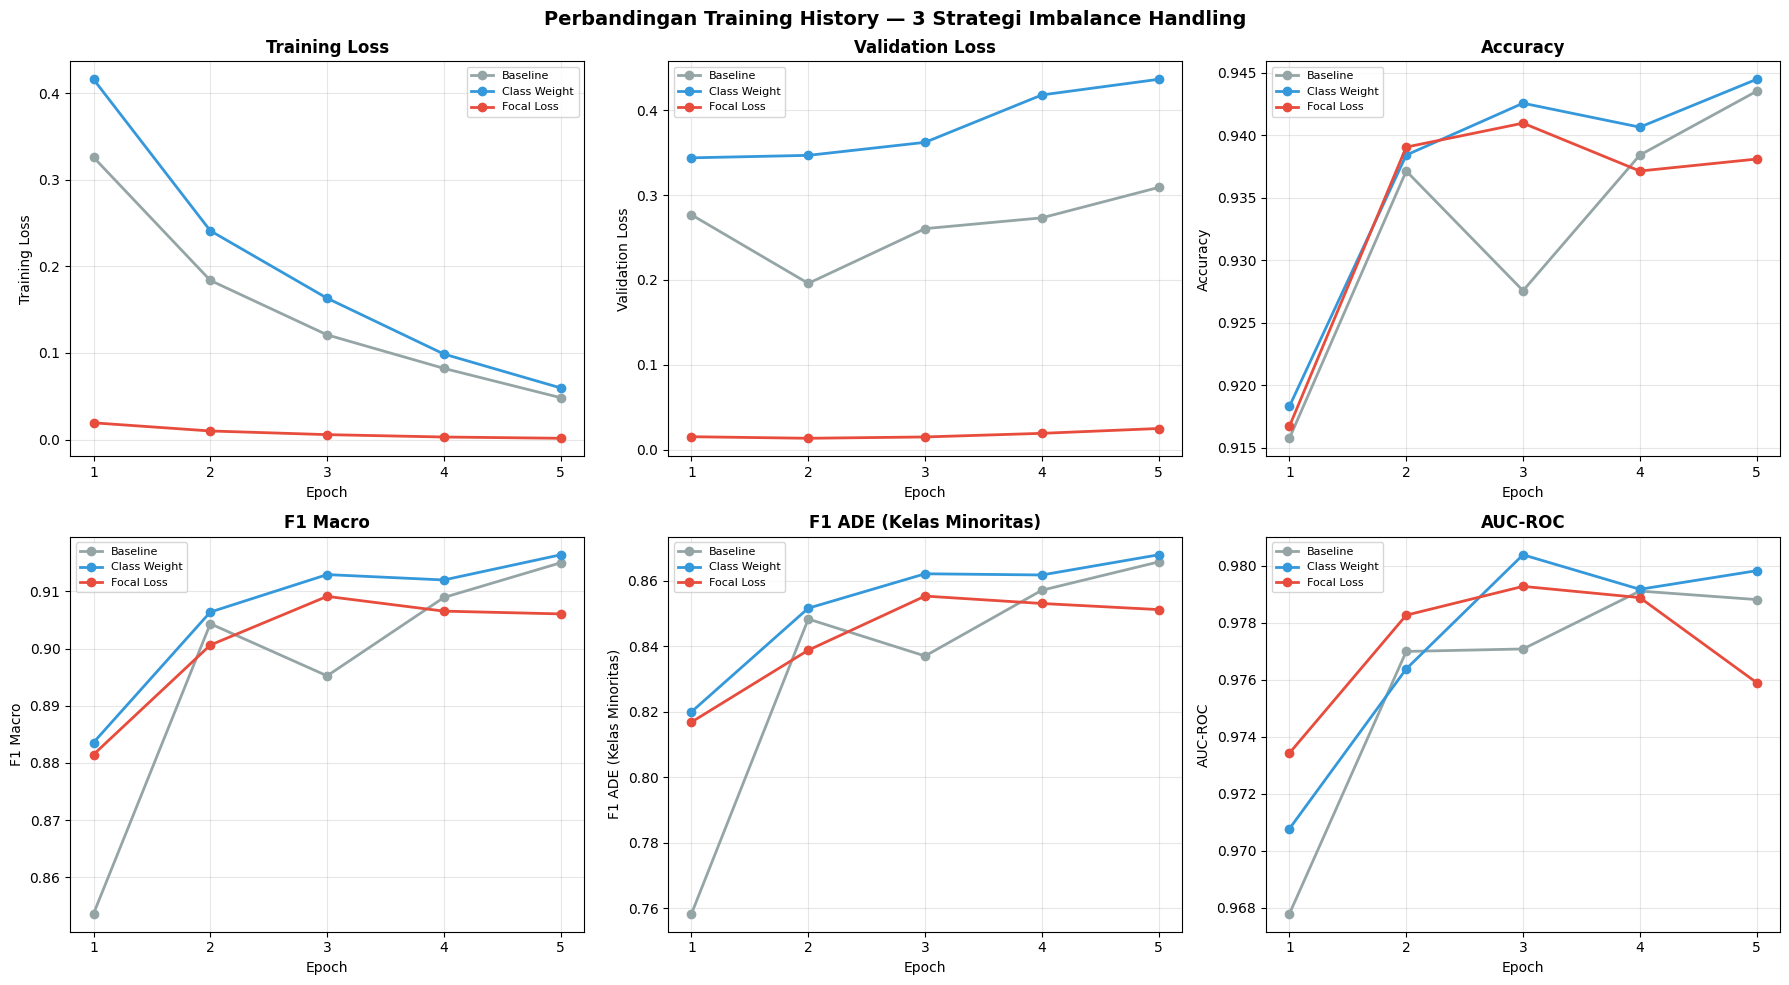

💾 Plot disimpan ke: experiment_comparison.png


In [10]:
print('='*65)
print('📊 PERBANDINGAN HASIL EKSPERIMEN')
print('='*65)
print(f'  {"Eksperimen":<30} {"Best F1 Macro":<16} {"Best F1 ADE":<14} {"Best Epoch"}')
print('  ' + '-'*65)

for key, res in experiment_results.items():
    best_row = max(res['history'], key=lambda r: r['f1_macro'])
    print(f'  {res["name"]:<30} {res["best_val_f1"]:<16.4f} {best_row["f1_ade"]:<14.4f} {res["best_epoch"]}')

# ── Plot Training History ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Perbandingan Training History — 3 Strategi Imbalance Handling', fontsize=14, fontweight='bold')

colors_exp = {'baseline': '#95a5a6', 'class_weight': '#3498db', 'focal_loss': '#e74c3c'}
metrics_to_plot = [
    ('train_loss', 'Training Loss'),
    ('val_loss',   'Validation Loss'),
    ('accuracy',   'Accuracy'),
    ('f1_macro',   'F1 Macro'),
    ('f1_ade',     'F1 ADE (Kelas Minoritas)'),
    ('auc_roc',    'AUC-ROC'),
]

for ax, (metric, title) in zip(axes.flatten(), metrics_to_plot):
    for key, res in experiment_results.items():
        epochs = [r['epoch'] for r in res['history']]
        values = [r[metric] for r in res['history']]
        label  = res['name'].replace(' (No Imbalance Handling)', '')
        ax.plot(epochs, values, marker='o', color=colors_exp[key], label=label, linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Plot disimpan ke: experiment_comparison.png')

## 🏆 CELL 11 — Pemilihan Model Terbaik

In [11]:
# ── Pilih model terbaik berdasarkan F1 Macro di validation ──
best_exp_key = max(experiment_results, key=lambda k: experiment_results[k]['best_val_f1'])
best_exp     = experiment_results[best_exp_key]

print('='*60)
print('🏆 MODEL TERBAIK TERPILIH')
print('='*60)
print(f'  Strategi    : {best_exp["name"]}')
print(f'  Best Epoch  : {best_exp["best_epoch"]}')
print(f'  Val F1 Macro: {best_exp["best_val_f1"]:.4f}')
print(f'  Training Time: {best_exp["training_time"]:.1f} detik')

# ── Load state dict terbaik ke model baru ──
print('\n⏳ Memuat best model state...')
best_model = build_model(MODEL_NAME, NUM_CLASSES, device)
best_model.load_state_dict(best_exp['best_model_state'])
best_model.to(device)
best_model.eval()
print('✅ Model terbaik siap untuk evaluasi final!')

# Catat ke MLflow sebagai final model
with mlflow.start_run(run_name=f'BEST_MODEL_{best_exp_key}'):
    mlflow.log_params({
        'best_strategy'  : best_exp_key,
        'best_epoch'     : best_exp['best_epoch'],
        'model_name'     : MODEL_NAME,
        'selection_metric': 'val_f1_macro',
    })
    mlflow.log_metric('best_val_f1_macro', best_exp['best_val_f1'])
    mlflow.pytorch.log_model(best_model, artifact_path='best_roberta_model')
    print(f'\n📝 Best model di-log ke MLflow experiment: {MLFLOW_EXPERIMENT}')

🏆 MODEL TERBAIK TERPILIH
  Strategi    : Class Weight
  Best Epoch  : 5
  Val F1 Macro: 0.9164
  Training Time: 1779.5 detik

⏳ Memuat best model state...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
2026/04/30 15:52:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/

✅ Model terbaik siap untuk evaluasi final!


2026/04/30 15:52:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/30 15:53:01 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



📝 Best model di-log ke MLflow experiment: RoBERTa_ADE_Imbalance_Comparison


## 🎯 CELL 12 — Threshold Tuning pada Best Model

🔍 Mencari threshold optimal di validation set...

✅ Threshold default (0.50):
   F1 Macro=0.9164  F1 ADE=0.8680  Recall ADE=0.8938

🏆 Threshold optimal (0.89):
   F1 Macro=0.9196  F1 ADE=0.8727  Recall ADE=0.8891


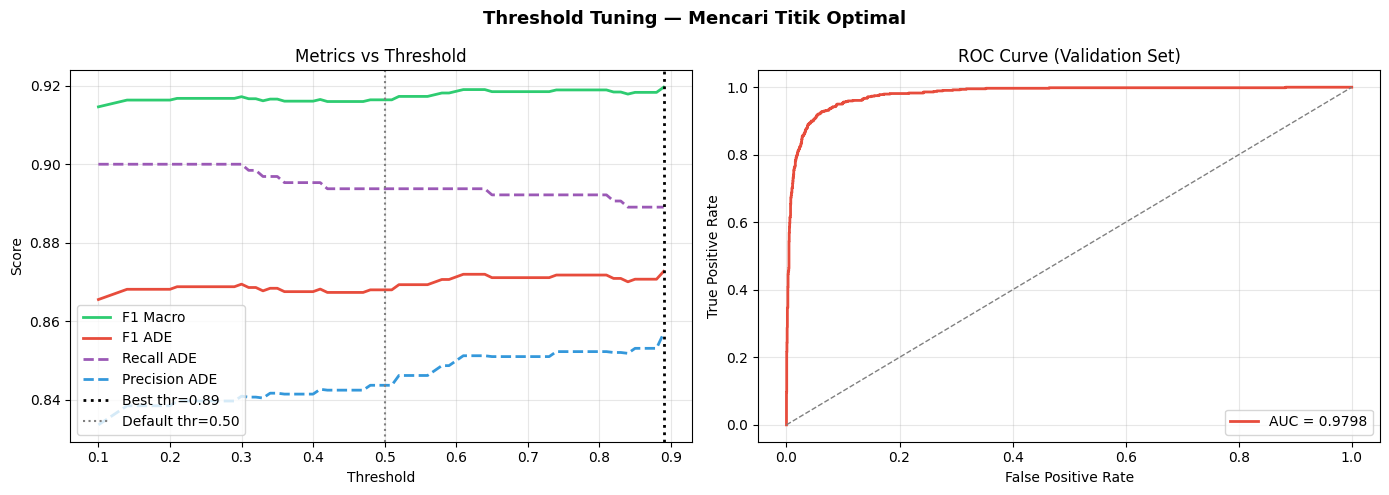

In [12]:
# ── Dapatkan probabilitas dari validation set ──
loss_fn_eval = nn.CrossEntropyLoss()  # hanya untuk compute loss
val_metrics_full = evaluate(best_model, val_loader, loss_fn_eval, device)
val_probs  = val_metrics_full['probs']
val_true   = val_metrics_full['labels']

# ── Grid search threshold terbaik ──
print('🔍 Mencari threshold optimal di validation set...')
thresholds = np.arange(0.10, 0.90, 0.01)
results_thr = []

for thr in thresholds:
    preds = (val_probs >= thr).astype(int)
    f1_m  = f1_score(val_true, preds, average='macro', zero_division=0)
    f1_a  = f1_score(val_true, preds, pos_label=1, average='binary', zero_division=0)
    rec_a = recall_score(val_true, preds, pos_label=1, zero_division=0)
    pre_a = precision_score(val_true, preds, pos_label=1, zero_division=0)
    results_thr.append({
        'threshold': thr, 'f1_macro': f1_m, 'f1_ade': f1_a,
        'recall_ade': rec_a, 'precision_ade': pre_a
    })

df_thr = pd.DataFrame(results_thr)
best_thr_row = df_thr.loc[df_thr['f1_macro'].idxmax()]
BEST_THRESHOLD = best_thr_row['threshold']

print(f'\n✅ Threshold default (0.50):')
default_row = df_thr[df_thr['threshold'].round(2) == 0.50].iloc[0]
print(f'   F1 Macro={default_row["f1_macro"]:.4f}  F1 ADE={default_row["f1_ade"]:.4f}  Recall ADE={default_row["recall_ade"]:.4f}')

print(f'\n🏆 Threshold optimal ({BEST_THRESHOLD:.2f}):')
print(f'   F1 Macro={best_thr_row["f1_macro"]:.4f}  F1 ADE={best_thr_row["f1_ade"]:.4f}  Recall ADE={best_thr_row["recall_ade"]:.4f}')

# ── Plot Threshold vs Metrics ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Threshold Tuning — Mencari Titik Optimal', fontsize=13, fontweight='bold')

axes[0].plot(df_thr['threshold'], df_thr['f1_macro'],    label='F1 Macro',    color='#2ecc71', lw=2)
axes[0].plot(df_thr['threshold'], df_thr['f1_ade'],      label='F1 ADE',      color='#e74c3c', lw=2)
axes[0].plot(df_thr['threshold'], df_thr['recall_ade'],  label='Recall ADE',  color='#9b59b6', lw=2, ls='--')
axes[0].plot(df_thr['threshold'], df_thr['precision_ade'], label='Precision ADE', color='#3498db', lw=2, ls='--')
axes[0].axvline(BEST_THRESHOLD, color='black', ls=':', lw=2, label=f'Best thr={BEST_THRESHOLD:.2f}')
axes[0].axvline(0.50, color='gray', ls=':', lw=1.5, label='Default thr=0.50')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ROC Curve
fpr, tpr, _ = roc_curve(val_true, val_probs)
auc_val = roc_auc_score(val_true, val_probs)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0,1], [0,1], color='gray', lw=1, ls='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Validation Set)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## 📋 CELL 13 — Evaluasi Final pada Test Set

🎯 EVALUASI FINAL — TEST SET

📊 Dengan Threshold Default (0.50):
              precision    recall  f1-score   support

 Non-ADE (0)     0.9747    0.9587    0.9666      2494
     ADE (1)     0.8490    0.9033    0.8753       641

    accuracy                         0.9474      3135
   macro avg     0.9118    0.9310    0.9210      3135
weighted avg     0.9490    0.9474    0.9480      3135


📊 Dengan Threshold Optimal (0.89):
              precision    recall  f1-score   support

 Non-ADE (0)     0.9728    0.9615    0.9671      2494
     ADE (1)     0.8567    0.8955    0.8757       641

    accuracy                         0.9480      3135
   macro avg     0.9148    0.9285    0.9214      3135
weighted avg     0.9491    0.9480    0.9484      3135



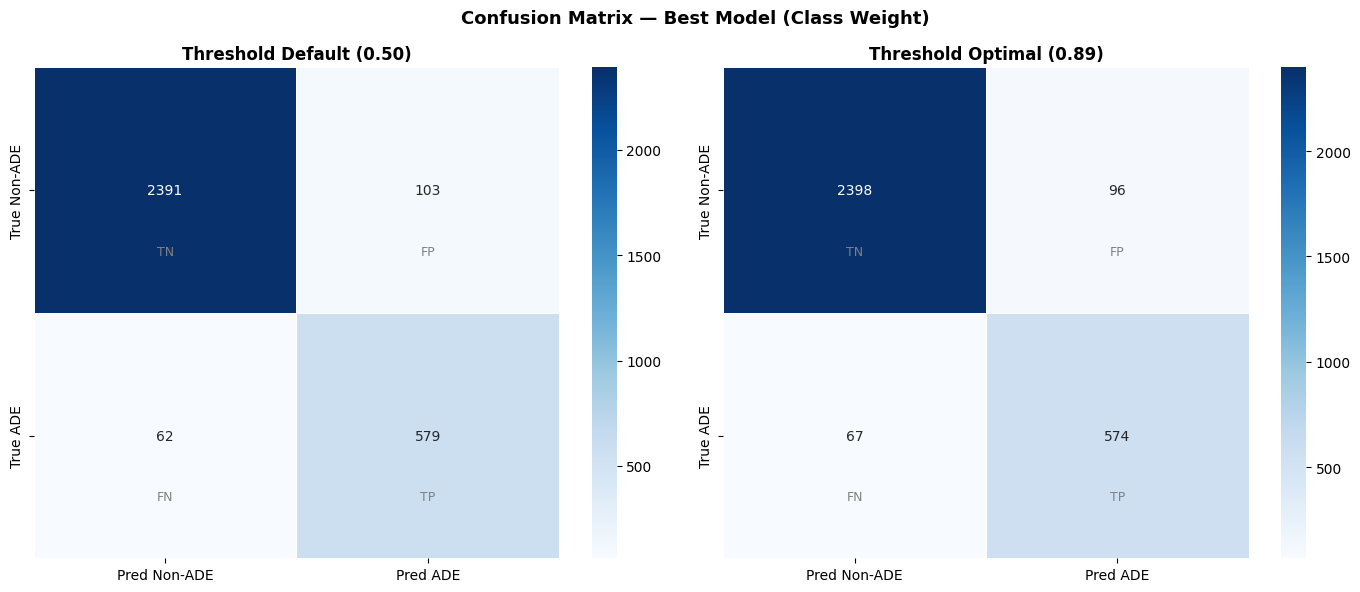


📈 RINGKASAN PERBANDINGAN THRESHOLD:
  Metrik                 Default (0.50)     Optimal (0.89)
  -------------------------------------------------------
  Accuracy               0.9474             0.9480  ↑0.0006
  F1 Macro               0.9210             0.9214  ↑0.0004
  F1 ADE                 0.8753             0.8757  ↑0.0004
  Recall ADE             0.9033             0.8955  ↓0.0078
  Precision ADE          0.8490             0.8567  ↑0.0077
  AUC-ROC                0.9803             0.9803  =0.0000


In [13]:
print('='*60)
print('🎯 EVALUASI FINAL — TEST SET')
print('='*60)

# Evaluasi dengan threshold default
test_metrics = evaluate(best_model, test_loader, loss_fn_eval, device)
test_probs   = test_metrics['probs']
test_true    = test_metrics['labels']

# Evaluasi dengan threshold optimal
test_preds_optimal = (test_probs >= BEST_THRESHOLD).astype(int)

print(f'\n📊 Dengan Threshold Default (0.50):')
print(classification_report(
    test_true, test_metrics['predictions'],
    target_names=['Non-ADE (0)', 'ADE (1)'],
    digits=4
))

print(f'\n📊 Dengan Threshold Optimal ({BEST_THRESHOLD:.2f}):')
print(classification_report(
    test_true, test_preds_optimal,
    target_names=['Non-ADE (0)', 'ADE (1)'],
    digits=4
))

# ── Confusion Matrix — Side by Side ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Confusion Matrix — Best Model ({best_exp["name"]})', fontsize=13, fontweight='bold')

for ax, preds, title in [
    (axes[0], test_metrics['predictions'], 'Threshold Default (0.50)'),
    (axes[1], test_preds_optimal,          f'Threshold Optimal ({BEST_THRESHOLD:.2f})')
]:
    cm = confusion_matrix(test_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Non-ADE', 'Pred ADE'],
                yticklabels=['True Non-ADE', 'True ADE'],
                linewidths=0.5, linecolor='white')
    ax.set_title(title, fontweight='bold')

    # Anotasi TN/FP/FN/TP
    labels_cm = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j+0.5, i+0.75, labels_cm[i][j], ha='center',
                    va='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ringkasan Numerik ──
print('\n📈 RINGKASAN PERBANDINGAN THRESHOLD:')
print(f'  {"Metrik":<22} {"Default (0.50)":<18} {f"Optimal ({BEST_THRESHOLD:.2f})"}')
print('  ' + '-'*55)
preds_def = test_metrics['predictions']
preds_opt = test_preds_optimal
for metric_name, fn in [
    ('Accuracy',      lambda p: accuracy_score(test_true, p)),
    ('F1 Macro',      lambda p: f1_score(test_true, p, average='macro')),
    ('F1 ADE',        lambda p: f1_score(test_true, p, pos_label=1, average='binary')),
    ('Recall ADE',    lambda p: recall_score(test_true, p, pos_label=1)),
    ('Precision ADE', lambda p: precision_score(test_true, p, pos_label=1, zero_division=0)),
    ('AUC-ROC',       lambda p: roc_auc_score(test_true, test_probs)),
]:
    v_def = fn(preds_def)
    v_opt = fn(preds_opt)
    delta = v_opt - v_def
    arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
    print(f'  {metric_name:<22} {v_def:<18.4f} {v_opt:.4f}  {arrow}{abs(delta):.4f}')

## 🔍 CELL 14 — Inferensi Real-time

In [14]:
def predict_ade(texts, model, tokenizer, threshold=BEST_THRESHOLD, max_length=MAX_LENGTH):
    """
    Prediksi ADE untuk satu atau beberapa kalimat.

    Args:
        texts (str | list): Satu kalimat atau list kalimat.
        model: Model RoBERTa yang sudah fine-tuned.
        tokenizer: Tokenizer RoBERTa.
        threshold (float): Ambang batas prediksi ADE.
        max_length (int): Panjang maksimum token.

    Returns:
        list of dict: Prediksi tiap kalimat.
    """
    if isinstance(texts, str):
        texts = [texts]

    model.eval()
    encodings = tokenizer(
        texts, truncation=True, padding='max_length',
        max_length=max_length, return_tensors='pt'
    )
    input_ids      = encodings['input_ids'].to(device)
    attention_mask = encodings['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()

    results = []
    for i, text in enumerate(texts):
        prob_ade   = probs[i][1]
        prob_nonade = probs[i][0]
        label      = 1 if prob_ade >= threshold else 0
        results.append({
            'text'       : text[:80] + '...' if len(text) > 80 else text,
            'prediction' : 'ADE ⚠️' if label == 1 else 'Non-ADE ✅',
            'label'      : label,
            'prob_ade'   : round(float(prob_ade), 4),
            'prob_nonade': round(float(prob_nonade), 4),
            'confidence' : round(float(max(prob_ade, prob_nonade)), 4),
        })
    return results


# ── Uji Inferensi ──
test_sentences = [
    "The patient developed severe nausea and vomiting after taking ibuprofen for three days.",
    "She was prescribed amoxicillin 500mg three times daily for a bacterial infection.",
    "Following administration of warfarin, the patient experienced significant internal bleeding.",
    "The doctor recommended regular exercise and a balanced diet to manage hypertension.",
    "Methotrexate therapy was associated with severe liver toxicity in several patients.",
]

print('='*65)
print(f'🔍 INFERENSI REAL-TIME (threshold={BEST_THRESHOLD:.2f})')
print('='*65)

preds = predict_ade(test_sentences, best_model, tokenizer)
for i, res in enumerate(preds, 1):
    print(f'\n[{i}] Teks       : {res["text"]}')
    print(f'    Prediksi   : {res["prediction"]}')
    print(f'    Prob ADE   : {res["prob_ade"]:.4f}  |  Prob Non-ADE: {res["prob_nonade"]:.4f}')
    print(f'    Confidence : {res["confidence"]:.4f}')

🔍 INFERENSI REAL-TIME (threshold=0.89)

[1] Teks       : The patient developed severe nausea and vomiting after taking ibuprofen for thre...
    Prediksi   : ADE ⚠️
    Prob ADE   : 0.9992  |  Prob Non-ADE: 0.0008
    Confidence : 0.9992

[2] Teks       : She was prescribed amoxicillin 500mg three times daily for a bacterial infection...
    Prediksi   : Non-ADE ✅
    Prob ADE   : 0.0001  |  Prob Non-ADE: 0.9999
    Confidence : 0.9999

[3] Teks       : Following administration of warfarin, the patient experienced significant intern...
    Prediksi   : ADE ⚠️
    Prob ADE   : 0.9989  |  Prob Non-ADE: 0.0011
    Confidence : 0.9989

[4] Teks       : The doctor recommended regular exercise and a balanced diet to manage hypertensi...
    Prediksi   : Non-ADE ✅
    Prob ADE   : 0.0001  |  Prob Non-ADE: 0.9999
    Confidence : 0.9999

[5] Teks       : Methotrexate therapy was associated with severe liver toxicity in several patien...
    Prediksi   : ADE ⚠️
    Prob ADE   : 0.9991  |  Prob 

## 💾 CELL 15 — Simpan Model Terbaik

In [15]:
SAVE_PATH = './roberta_ade_best_model'
os.makedirs(SAVE_PATH, exist_ok=True)

# Simpan model & tokenizer
best_model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

# Simpan konfigurasi eksperimen terbaik
model_card = {
    'model_name'          : MODEL_NAME,
    'task'                : 'ADE Binary Classification',
    'dataset'             : 'ADE-Corpus-V2 (Gurulingappa et al., 2012)',
    'dataset_hash'        : dataset_hash,
    'best_strategy'       : best_exp_key,
    'best_epoch'          : best_exp['best_epoch'],
    'optimal_threshold'   : round(float(BEST_THRESHOLD), 4),
    'val_f1_macro'        : round(best_exp['best_val_f1'], 4),
    'test_f1_macro_default': round(f1_score(test_true, test_metrics['predictions'], average='macro'), 4),
    'test_f1_macro_optimal': round(f1_score(test_true, test_preds_optimal, average='macro'), 4),
    'test_auc_roc'        : round(roc_auc_score(test_true, test_probs), 4),
    'hyperparameters': {
        'max_length'  : MAX_LENGTH,
        'batch_size'  : BATCH_SIZE,
        'num_epochs'  : NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'warmup_ratio': WARMUP_RATIO,
    },
    'saved_at': datetime.datetime.now().isoformat()
}

with open(f'{SAVE_PATH}/model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print(f'✅ Model disimpan ke: {SAVE_PATH}/')
print(f'\n📁 File tersimpan:')
for fname in os.listdir(SAVE_PATH):
    size = os.path.getsize(os.path.join(SAVE_PATH, fname)) / (1024**2)
    print(f'   {fname:<40} ({size:.2f} MB)')

print('\n💡 Cara load model:')
print(f"""
from transformers import RobertaTokenizer, RobertaForSequenceClassification
import json

model     = RobertaForSequenceClassification.from_pretrained('{SAVE_PATH}')
tokenizer = RobertaTokenizer.from_pretrained('{SAVE_PATH}')

with open('{SAVE_PATH}/model_card.json') as f:
    cfg = json.load(f)
threshold = cfg['optimal_threshold']  # {BEST_THRESHOLD:.2f}
""")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model disimpan ke: ./roberta_ade_best_model/

📁 File tersimpan:
   model_card.json                          (0.00 MB)
   tokenizer.json                           (3.39 MB)
   config.json                              (0.00 MB)
   model.safetensors                        (475.51 MB)
   tokenizer_config.json                    (0.00 MB)

💡 Cara load model:

from transformers import RobertaTokenizer, RobertaForSequenceClassification
import json

model     = RobertaForSequenceClassification.from_pretrained('./roberta_ade_best_model')
tokenizer = RobertaTokenizer.from_pretrained('./roberta_ade_best_model')

with open('./roberta_ade_best_model/model_card.json') as f:
    cfg = json.load(f)
threshold = cfg['optimal_threshold']  # 0.89



## 📊 CELL 16 — MLflow Summary & Model Registry

In [16]:
# ── Tampilkan semua run dari MLflow ──
print('='*65)
print('📊 MLflow EXPERIMENT SUMMARY')
print('='*65)

client = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name(MLFLOW_EXPERIMENT)

if experiment:
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=['metrics.best_val_f1_macro DESC']
    )

    print(f'  Experiment: {MLFLOW_EXPERIMENT}')
    print(f'  Total runs: {len(runs)}')
    print()
    print(f'  {"Run Name":<35} {"F1 Macro":<12} {"Status"}')
    print('  ' + '-'*60)
    for run in runs:
        name    = run.data.tags.get('mlflow.runName', 'N/A')
        f1      = run.data.metrics.get('best_val_f1_macro', 0)
        status  = run.info.status
        print(f'  {name:<35} {f1:<12.4f} {status}')
else:
    print('  MLflow experiment tidak ditemukan secara lokal.')

# ── Final Summary ──
print('\n' + '='*65)
print('✅ PIPELINE SELESAI — RINGKASAN AKHIR')
print('='*65)
summary_rows = [
    ('Dataset', f'ADE-Corpus-V2  |  {len(df):,} sampel  |  hash:{dataset_hash}'),
    ('Strategi terbaik', best_exp['name']),
    ('Best epoch', str(best_exp['best_epoch'])),
    ('Optimal threshold', f'{BEST_THRESHOLD:.2f}'),
    ('Test F1 Macro (default)', f"{f1_score(test_true, test_metrics['predictions'], average='macro'):.4f}"),
    ('Test F1 Macro (optimal thr)', f'{f1_score(test_true, test_preds_optimal, average="macro"):.4f}'),
    ('Test F1 ADE (optimal thr)', f'{f1_score(test_true, test_preds_optimal, pos_label=1, average="binary"):.4f}'),
    ('Test AUC-ROC', f'{roc_auc_score(test_true, test_probs):.4f}'),
    ('Model disimpan', SAVE_PATH),
    ('Experiment tracker', f'MLflow — {MLFLOW_EXPERIMENT}'),
]
for k, v in summary_rows:
    print(f'  {k:<30}: {v}')

📊 MLflow EXPERIMENT SUMMARY
  Experiment: RoBERTa_ADE_Imbalance_Comparison
  Total runs: 4

  Run Name                            F1 Macro     Status
  ------------------------------------------------------------
  BEST_MODEL_class_weight             0.9164       FINISHED
  Class Weight                        0.9164       FINISHED
  Baseline (No Imbalance Handling)    0.9150       FINISHED
  Focal Loss                          0.9091       FINISHED

✅ PIPELINE SELESAI — RINGKASAN AKHIR
  Dataset                       : ADE-Corpus-V2  |  20,896 sampel  |  hash:10469a693dd4
  Strategi terbaik              : Class Weight
  Best epoch                    : 5
  Optimal threshold             : 0.89
  Test F1 Macro (default)       : 0.9210
  Test F1 Macro (optimal thr)   : 0.9214
  Test F1 ADE (optimal thr)     : 0.8757
  Test AUC-ROC                  : 0.9803
  Model disimpan                : ./roberta_ade_best_model
  Experiment tracker            : MLflow — RoBERTa_ADE_Imbalance_Comparison


---
## ✅ Pipeline Selesai!

| Tahap | Fitur | Status |
|-------|-------|--------|
| Load Dataset | ADE-Corpus-V2 dari HuggingFace | ✅ |
| Dataset Tracking | Hash, metadata, split versioning | ✅ |
| EDA | Distribusi label, panjang teks, visualisasi | ✅ |
| Tokenisasi | RoBERTa tokenizer, padding, truncation | ✅ |
| Imbalanced Handling | Baseline vs Class Weight vs Focal Loss | ✅ |
| MLflow Logging | Params, metrics, artifacts per epoch | ✅ |
| Model Terbaik | Auto-select berdasarkan val F1 Macro | ✅ |
| Threshold Tuning | Grid search threshold optimal | ✅ |
| Evaluasi Final | Classification report + Confusion Matrix | ✅ |
| Inferensi | Real-time prediction dengan threshold | ✅ |
| Simpan Model | Model card + weights + tokenizer | ✅ |

---
*Pipeline ADE Detection — RoBERTa + Imbalance Handling + MLflow*